In [15]:
import numpy as np
# from numpy.fft import fft, fftfreq
from pyfftw.interfaces.numpy_fft import fft, fftfreq
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.signal.windows import blackman
from scipy.optimize import curve_fit

In [16]:
def format_data(data, data_gate, aclk_freq, words_per_packet, header_words):

    buffer_gate_np = np.array(data_gate)
    buffer_nonzero = buffer_gate_np[buffer_gate_np != 0]
    buffer_gate_np = None
    rising_edge_mask = ((buffer_nonzero & (1 << 63)) >> 63) == 0
    rising_edges = buffer_nonzero[rising_edge_mask]
    falling_edges = buffer_nonzero[~rising_edge_mask] & ((1 << 63) - 1)
    buffer_nonzero = None
    rising_edges = rising_edges.astype(np.float64) / aclk_freq
    falling_edges = falling_edges.astype(np.float64) / aclk_freq
    
    edge_times = np.array([rising_edges, falling_edges]).T
    rising_edges, falling_edges = None, None
    
    buffer_np = np.frombuffer(data, dtype=np.uint64)        
    
    num_words = buffer_np.size
    
    expected_magic_word_indices = np.arange(int(num_words / words_per_packet)) * words_per_packet
    expected_metadata_mask = np.full(buffer_np.size, False)
    expected_metadata_mask[expected_magic_word_indices] = True
    expected_magic_word_indices = None
    for _ in range(header_words-1):
        expected_metadata_mask |= np.roll(expected_metadata_mask, 1)
        
    first_ts = buffer_np[header_words-1]

    buffer_np = buffer_np[~expected_metadata_mask]
    buffer_np = np.frombuffer(buffer_np.byteswap(), dtype=np.uint8).reshape((-1,3)).astype(np.uint32)

    buffer_np = (buffer_np[:,0]<<16) + (buffer_np[:,1]<<8) + (buffer_np[:,2])

    buffer_np = buffer_np << 8
    buffer_np = buffer_np.astype(np.int32)
    buffer_np = buffer_np >> 8

    buffer_np = buffer_np.reshape((-1,8)).T
    
    return buffer_np, first_ts, edge_times

def process_to_dc(iq_data, samp_freq, fft_bins=1, phase_rotate=True):

    num_samp = iq_data.shape[1]

    # Reshape the data so axis 1 indexes the different fft bins
    new_num_samps = num_samp - num_samp%fft_bins
    bin_samps = int(new_num_samps/fft_bins)
    iq_data = iq_data[:,:new_num_samps]
    iq_data = iq_data.reshape((-1,fft_bins,bin_samps))
    print(f'New number of samples (after FFT binning): {new_num_samps}')

    # Get FFT data and freq domain and sort (fftfreq doesn't give freqs back in ascending order)
    freq_domain = fftfreq(bin_samps, 1/samp_freq)
    freq_sort = np.argsort(freq_domain)
    freq_domain = freq_domain[freq_sort]
    iq_data_freq = fft(blackman(bin_samps)*iq_data, axis=2)[:,:,freq_sort]
    freq_sort = None

    if True:
        print('Finishesd FFTing')

    # Finds index of the highest-power signal (i.e. the carrier)
    carrier_indices = np.argmax(np.abs(iq_data_freq), axis=2)

    # Slices of indices immediately (3 away) around carrier index
    slices = carrier_indices[:,:,np.newaxis] + np.arange(-3, 4)[np.newaxis,np.newaxis,:]

    # Frequencies around carrier frequency
    freq_neighborhoods = freq_domain[slices]
  
    # FFT spectrum around carrier frequency
    iq_data_freq_neighborhoods = np.abs(np.take_along_axis(iq_data_freq, slices, axis=2))
    slices = None, None

    # Carrier frequency is found by weighted average of frequencies around the highest-power one. Since DC peak is not a delta, since if the true frequency is shifting, power is shifting among the FFT bins. 
    carrier_freqs = np.sum(freq_neighborhoods * iq_data_freq_neighborhoods/(np.sum(iq_data_freq_neighborhoods, axis=2)[:,:,np.newaxis]), axis=2)
    iq_data_freq_neighborhoods, freq_neighborhoods = None, None

    # Downmixes data
    iq_data = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs[:,:,np.newaxis]/samp_freq*np.arange(bin_samps)))
    carrier_freqs = None

    if phase_rotate:


        # Phases of the carrier signal
        carrier_phases = np.unwrap(np.angle(np.take_along_axis(iq_data_freq, carrier_indices[:,:,np.newaxis], axis=2))).squeeze(axis=2)
        iq_data_freq, carrier_indices = None, None

        # Eliminates any phase due to the carrier
        iq_data = iq_data * np.exp(-1j * carrier_phases[:,:,np.newaxis])
        carrier_phases = None


        # Takes away any remnant phases between I/Q data
        avg_phases = np.average(np.unwrap(np.angle(iq_data)), axis=2) # unwrap is very important here b/c we're averaging. if angle is fluctuating around +/- pi, the average of np.angle() could be ~0, but average of np.unwrap(np.angle()) will be the correct phase
        iq_data *= np.exp(-1j*avg_phases[:,:,np.newaxis])
        avg_phases = None

    else:

        iq_data_freq = None
        iq_data = np.abs(iq_data)

    iq_data = iq_data.reshape((-1, new_num_samps))

    return np.real(iq_data).astype(np.float64)    

def gate_means(data, times, gates):
    """
    data:  (4, N) detector data
    times: (N,)   sample times (constant spacing, assumed sorted)
    gates: (M, 2) [start, stop] times; uses start <= t < stop
    returns: (4, K) mean of data within each fully-contained gate, K <= M.
             Gates that are not fully covered by the data are dropped.
    """
    starts = gates[:, 0]
    stops = gates[:, 1]

    N = data.shape[1]
    lo = np.searchsorted(times, starts, side='left')
    hi = np.searchsorted(times, stops,  side='left')

    # A gate is fully contained iff:
    #   - its start is within the time range: start >= times[0]   -> lo < N (and start not before data)
    #   - its stop does not run past the data: hi < N (there is a sample at/after stop,
    #     meaning the data extends beyond the gate end)
    keep = (starts >= times[0]) & (hi < N) & (hi > lo)

    csum = np.concatenate(
        [np.zeros((data.shape[0], 1), dtype=np.float64),
         np.cumsum(data, axis=1, dtype=np.float64)],
        axis=1,
    )

    counts = hi - lo
    sums = csum[:, hi[keep]] - csum[:, lo[keep]]
    means = sums / counts[keep]

    return means

def plot_nice_ddf(ddfs, rdf1, rdf2, ch1_name, ch2_name, dir_path):

    fig, axs = plt.subplots(2,2, figsize=(10,8))
    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)

    n, bins, _ = axs[0,0].hist(rdf1, bins=100, histtype='step', color='purple', orientation='horizontal')
    axs[0,0].text(0.15*np.max(n), 0.85*bins[-1], f'$\\sigma={round(np.std(rdf1), 2)}$ ppm', fontdict=dict(size=14))
    axs[0,0].set_xscale('log')
    axs[0,0].minorticks_on()
    axs[0,0].xaxis.tick_top()
    axs[0,0].set_ylabel(f'{ch2_name} rel. diff. (ppm)')

    h = axs[0,1].hist2d(rdf1, rdf2, bins=100, cmap='turbo', norm=LogNorm())
    axs[0,1].set_xticks([])
    axs[0,1].set_yticks([])
    pos = axs[0, 1].get_position()

    # Create a new axis for the colorbar
    cbar_ax = fig.add_axes([
        pos.x1 + 0.01,  # x: slightly to the right of axs[0,1]
        pos.y0,         # y: same bottom as axs[0,1]
        0.02,           # width of colorbar
        pos.height      # same height as axs[0,1]
    ])
    fig.colorbar(h[3], cax=cbar_ax)

    n, bins, _ = axs[1,0].hist(ddfs, bins=100, histtype='step', color='purple')
    if np.std(ddfs) >= 0.5:
        bin_centers = (bins[:-1] + 0.5*np.diff(bins))
        def mygaussian(x, N, sigma, mu):
            return N/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*(x-mu)*(x-mu)/(sigma*sigma))
        p0 = [np.sum(n), np.std(ddfs), 0]
        popt_ddf, pcov = curve_fit(mygaussian, bin_centers, n, p0=p0)
        mygauss_domain = np.linspace(bin_centers[0], bin_centers[-1], 300)
        axs[1,0].plot(mygauss_domain, mygaussian(mygauss_domain, *popt_ddf), color='teal')
    try:
        axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(popt_ddf[1], 2)}$ ppm', fontdict=dict(size=14))
        popt_ddf = None
    except:
        axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(ddfs), 2)}$ ppm', fontdict=dict(size=14))
        # axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(ddfs), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,0].set_yscale('log')
    axs[1,0].minorticks_on()
    axs[1,0].set_xlabel(f'{ch1_name} - {ch2_name} ddf (ppm)')

    n, bins, _ = axs[1,1].hist(rdf2, bins=100, histtype='step', color='purple')
    axs[1,1].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(rdf2), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,1].set_yscale('log')
    axs[1,1].minorticks_on()
    axs[1,1].yaxis.tick_right()
    axs[1,1].set_xlabel(f'{ch2_name} rel. diff (ppm)')

    # fig.savefig(dir_path + 'ddf_plot')
    
    return

In [17]:
data = r'/home/cameron/Desktop/research/moller_rfsoc_sw/data/20260627-02_data'
data_gate = r'/home/cameron/Desktop/research/moller_rfsoc_sw/data/20260627-02_data_gate'

ACLK_FREQ = 125e6
HEADER_WORDS = 2
WORDS_PER_PACKET = 124928

In [18]:
data = np.fromfile(data, dtype=np.uint64)
data_gate = np.fromfile(data_gate, dtype=np.uint64)

In [19]:
buffer_np, first_ts, edge_times = format_data(data, data_gate, ACLK_FREQ, WORDS_PER_PACKET, HEADER_WORDS)
data = None
data_gate = None

In [20]:
even_mask = np.arange(buffer_np.shape[0])%2 == 0
buffer_np = buffer_np[even_mask,:] + 1j * buffer_np[~even_mask,:]

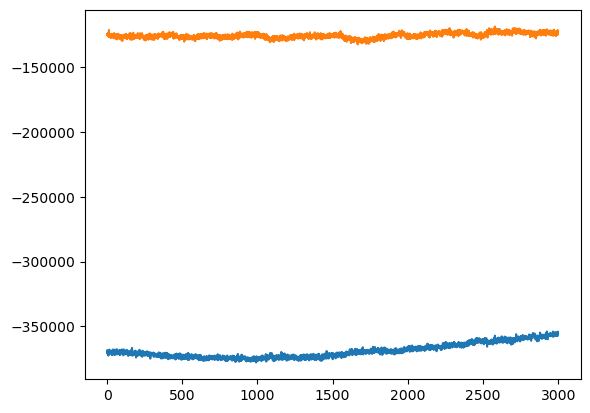

0.519692096
0


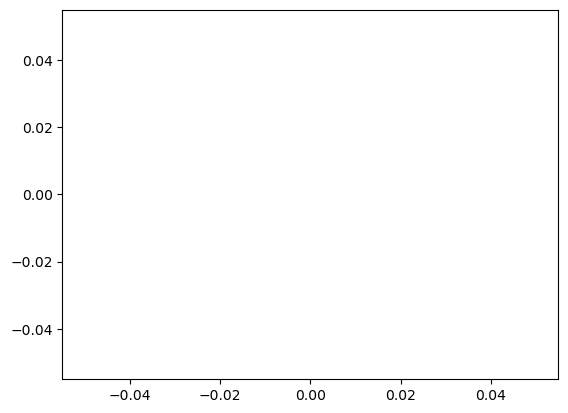

In [21]:
fig, ax = plt.subplots()
ax.plot(np.real(buffer_np[3,:3000]))
ax.plot(np.imag(buffer_np[3,:3000]))
plt.show()

time_domain = np.arange(buffer_np.shape[1]) / (5e9 / 320)
print(time_domain[-1])
mask = (time_domain >= 0.5200) & (time_domain < 0.521875)
print(mask.sum())

fig, ax = plt.subplots()
ax.plot(np.real(buffer_np[2,mask]))
ax.plot(np.real(buffer_np[3,mask]))
plt.show()

In [22]:
print(first_ts/ACLK_FREQ)
print(edge_times.shape)
print(edge_times[0])

2318.013550296
(1000, 2)
[2318.0136833  2318.01418414]


In [23]:
dc_data = process_to_dc(buffer_np, 5e9 / 320, fft_bins=10, phase_rotate=True)
print(dc_data.shape)

New number of samples (after FFT binning): 8120190
Finishesd FFTing
(4, 8120190)


In [24]:
print(dc_data.shape)
print(edge_times.shape)
print(dc_data.dtype)

(4, 8120190)
(1000, 2)
float64


In [25]:
# fig, ax = plt.subplots()
# ax.plot(dc_data[2,:])
# plt.show()

print(dc_data[2].std())
print(dc_data[3].std())

9742.310967867175
8915.032794827186


In [26]:
time_domain = first_ts/ACLK_FREQ + np.arange(dc_data.shape[1]) / (5e9 / 320)
integrated_data = gate_means(dc_data, time_domain, edge_times)

In [27]:
print(integrated_data.shape)
print(integrated_data[2])

(4, 997)
[417442.77616695 415920.57094413 419516.12667384 419582.15069278
 416017.1199368  417480.74741276 420312.61661272 417689.46271786
 415799.6407157  419297.49253311 419870.51323224 416205.67794204
 417038.4299406  420435.1722246  418032.0767434  415731.19903682
 419045.27604342 420028.87936819 416330.91624958 416661.37296832
 420260.37060326 418262.42506353 415593.55515717 418532.73657066
 420183.87548404 416492.08101392 416581.87860523 420045.01217154
 418663.80854727 415810.27226972 418448.42331857 420299.00312044
 416868.96272838 416354.16041087 419903.2026726  418751.01993167
 415733.31948124 417837.11147674 420468.07575893 417103.61008396
 416032.1947101  419720.11599093 419338.49133253 415916.62872968
 417659.83382591 420433.49618649 417523.07708739 415935.67160267
 419608.0501056  419722.30638426 416232.88836346 417375.23229865
 420452.84585706 417799.82788113 416042.03796358 419282.66884695
 419655.47691651 416173.15105218 417105.06240132 420461.44193224
 418262.74344136

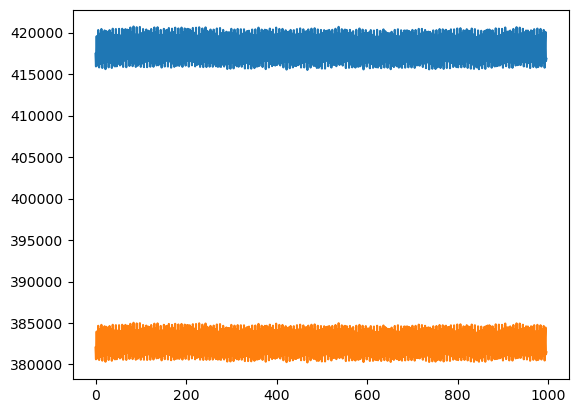

In [28]:
fig, ax = plt.subplots()
ax.plot(integrated_data[2])
ax.plot(integrated_data[3])
plt.show()

In [29]:
if integrated_data.shape[1]%2 != 0:
    integrated_data = integrated_data[:,:-1]

even_mask = np.arange(integrated_data.shape[1])%2 == 0
rdfs = (integrated_data[:,even_mask] - integrated_data[:,~even_mask]) / (integrated_data[:,even_mask] + integrated_data[:,~even_mask]) 
print(rdfs.shape)

(4, 498)


3090.163555199246
3088.9045655684795


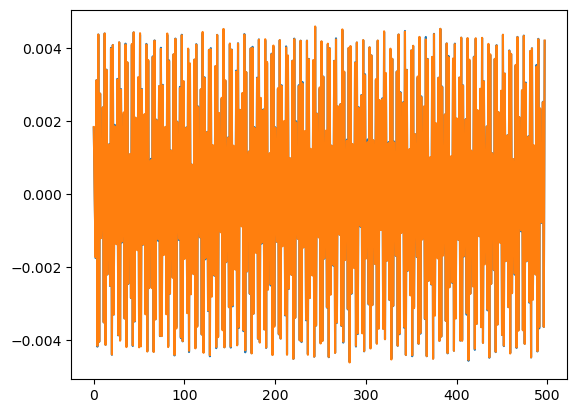

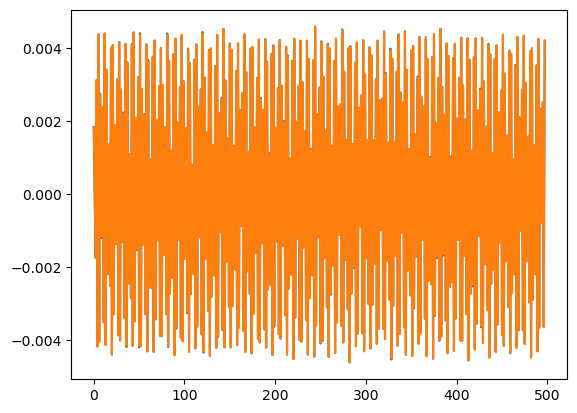

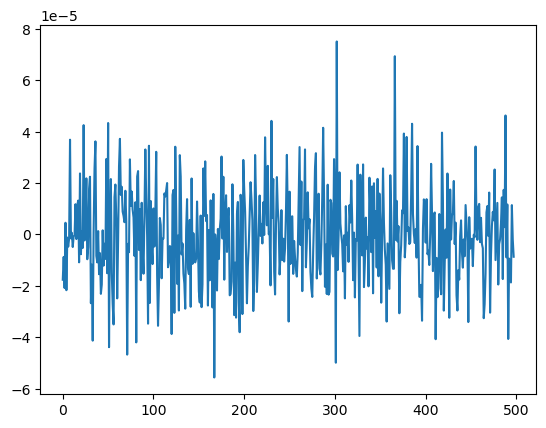

[-0.00077308 -0.00079405  0.00253605 -0.00364911  0.00420913]


In [30]:
ddfs = rdfs[2] - rdfs[3]
# ddfs = ddfs[:-1]
print(rdfs[2].std()*1e6)
print(rdfs[3].std()*1e6)

fig, ax = plt.subplots()
ax.plot(rdfs[2])
ax.plot(rdfs[3])
plt.show()

fig, ax = plt.subplots()
ax.plot(rdfs[3])
ax.plot(rdfs[2])
plt.show()

fig, ax = plt.subplots()
ax.plot(ddfs)
plt.show()

print(rdfs[2][-5:])

In [31]:
# print(dc_data.shape)
# fig, ax = plt.subplots()
# ax.plot(dc_data[2][-5000:])
# plt.show()

In [32]:
print(ddfs.mean())
print(ddfs.std()*1e6 * 1/np.sqrt(2))

-3.659663628911999e-07
13.05972720827331


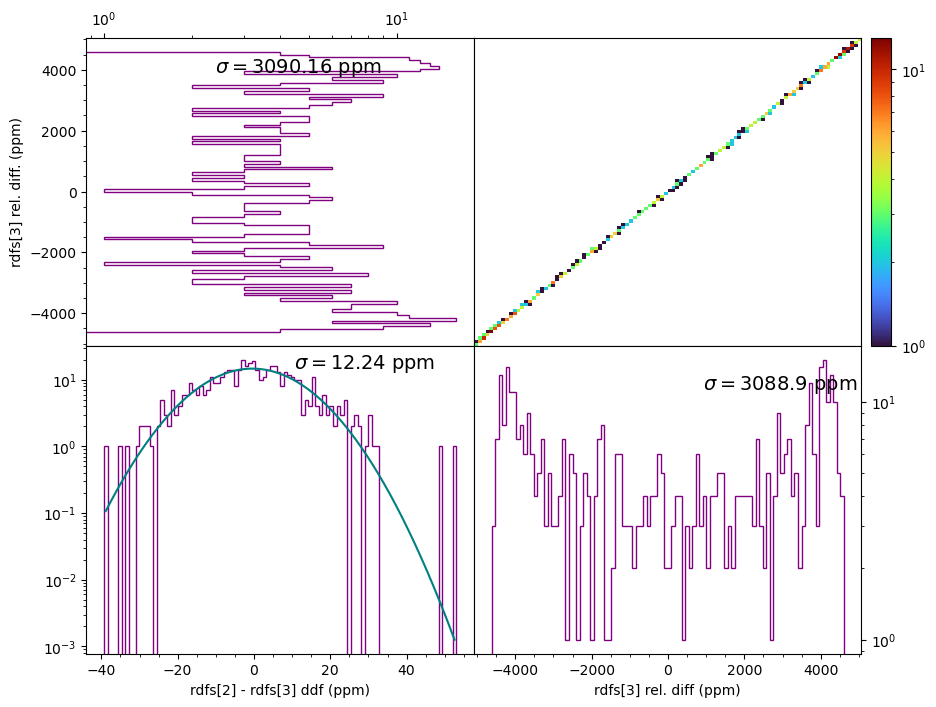

In [34]:
plot_nice_ddf(ddfs*1e6/np.sqrt(2), rdfs[2]*1e6, rdfs[3]*1e6, 'rdfs[2]', 'rdfs[3]', 'asdf')
# plot_nice_ddf((rdfs[1]-rdfs[2])*1e6/np.sqrt(2), rdfs[1]*1e6, rdfs[2]*1e6, 'rdfs[1]', 'rdfs[2]', 'asdf')
# plot_nice_ddf((rdfs[1]-rdfs[3])*1e6/np.sqrt(2), rdfs[1]*1e6, rdfs[3]*1e6, 'rdfs[1]', 'rdfs[3]', 'asdf')

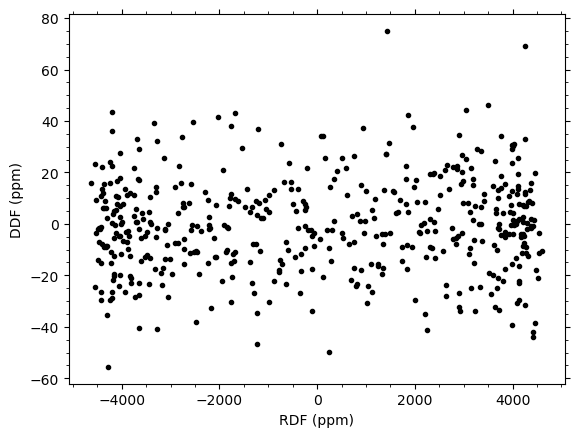

In [37]:
fig, ax = plt.subplots()
ax.scatter(rdfs[3]*1e6, ddfs*1e6, marker='.', color='black')
ax.set_xlabel('RDF (ppm)')
ax.set_ylabel('DDF (ppm)')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.xaxis.minorticks_on()
ax.yaxis.minorticks_on()
plt.show()

   -4392  mean= -2.575  se= 2.974  (-0.9 sigma)
   -3931  mean= -1.702  se= 2.078  (-0.8 sigma)
   -3470  mean= -0.991  se= 3.566  (-0.3 sigma)
   -3008  mean= -4.442  se= 3.724  (-1.2 sigma)
   -2547  mean= -1.056  se= 3.918  (-0.3 sigma)
   -2086  mean= -1.305  se= 4.150  (-0.3 sigma)
   -1624  mean=  3.220  se= 4.458  (+0.7 sigma)
   -1163  mean= -4.690  se= 4.200  (-1.1 sigma)
    -701  mean= -0.428  se= 4.759  (-0.1 sigma)
    -240  mean= -4.086  se= 2.921  (-1.4 sigma)
     221  mean=  2.994  se= 6.215  (+0.5 sigma)
     683  mean= -1.148  se= 4.085  (-0.3 sigma)
    1144  mean= -5.467  se= 3.836  (-1.4 sigma)
    1605  mean= 13.811  se= 5.273  (+2.6 sigma)
    2067  mean= -1.623  se= 4.928  (-0.3 sigma)
    2528  mean=  3.192  se= 3.816  (+0.8 sigma)
    2990  mean=  4.397  se= 3.533  (+1.2 sigma)
    3451  mean=  0.268  se= 4.528  (+0.1 sigma)
    3912  mean=  1.148  se= 2.602  (+0.4 sigma)
    4374  mean= -1.582  se= 3.028  (-0.5 sigma)


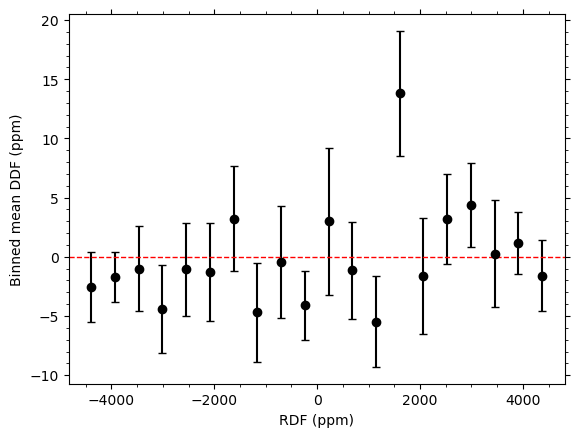

In [45]:
import numpy as np
import matplotlib.pyplot as plt

rdf = rdfs[3]
ddf = ddfs

bins = np.linspace(rdf.min(), rdf.max(), 21)
idx = np.digitize(rdf, bins)

centers, means, ses = [], [], []
for b in range(1, len(bins)):
    sel = idx == b
    n = sel.sum()
    if n > 1:
        m = ddf[sel].mean()
        se = ddf[sel].std(ddof=1) / np.sqrt(n)
        center = 0.5 * (bins[b-1] + bins[b])
        centers.append(center)
        means.append(m)
        ses.append(se)
        print(f"{center*1e6:8.0f}  mean={m*1e6:7.3f}  se={se*1e6:6.3f}  ({m/se:+.1f} sigma)")

centers = np.array(centers)
means = np.array(means)
ses = np.array(ses)

fig, ax = plt.subplots()
ax.errorbar(centers*1e6, means*1e6, yerr=ses*1e6, fmt='o', capsize=3, color='black')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('RDF (ppm)')
ax.set_ylabel('Binned mean DDF (ppm)')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.xaxis.minorticks_on()
ax.yaxis.minorticks_on()
plt.show()